# 손가락 움직임 회귀(regression) 디코더로 AmazingHand 구동

`neural-to-output` 프로젝트와 독립적인 sandbox입니다 (`pyproject.toml`/`uv.lock` 미수정, `01_explore_eeg_decoder.ipynb`와
같은 `examples` 의존성 그룹만 사용합니다).

**목표**: `04_hand_intent_classification_amazinghand.ipynb`가 이산적인 gesture 라벨을 분류했다면,
이 노트북은 손가락마다 연속적인 굴곡도(flexion, 0=완전히 펴짐 ~ 1=완전히 쥐어짐)를 예측하는 **회귀** 디코더를
만들고, 그 출력을 `AmazingHand`까지 전달합니다. 04번 노트북과 마찬가지로, 실제 [AmazingHand]
(https://github.com/pollen-robotics/AmazingHand) CAD로 만든 MuJoCo 모델을 직접 관절 제어해서 손이
움직이는 모습을 봅니다.

**로봇 자유도(DoF) 관련 참고**: AmazingHand는 실제로 4개의 동일한 평행 메커니즘 손가락(`finger1`~`finger4`)을
가지고, 손가락마다 2개 서보(굴곡/신전용 `motor1`, 외전/내전용 `motor2`)로 움직이는 총 8-DoF 손입니다
(04번 노트북에서 쓴 것과 같은 CAD 모델 — 출처/라이선스는 `examples/robot/hand/amazing_hand_right/NOTICE.md` 참고).
여기서는 그중 굴곡(`motor1`) 축만 손가락별로 연속값으로 예측하고, 외전(`motor2`) 축은 중립(0)으로 고정합니다.

**데이터셋 관련 캐비잇**: EEG와 손가락 운동학(kinematics)을 동시에 기록한 공개 데이터셋(예: WAY-EEG-GAL,
Luciw et al. 2014)은 실존하지만 수 GB 단위라 이 프로젝트의 `examples` 의존성 그룹에는 포함되어 있지 않습니다.
여기서는 손가락 굴곡도와 상관된 **합성(synthetic) 신호**로 회귀 디코더의 입출력 shape과 학습/추론 흐름을
보여줍니다 — 실제 기록으로 바꾸더라도 `n2o.signal.dataset`에 새 `DatasetLoader` 구현 하나만 추가하면 아래
디코더/로봇 연결 코드는 그대로 재사용됩니다.

**하드웨어 관련 캐비잇**: `n2o.robot.hand.AmazingHand`는 이제 `rustypot` 기반 실제 서보 드라이버입니다
(`n2o.robot.Part`를 상속) — `move(cmd)`가 실제 하드웨어를 구동하고, `goal(cmd)`는 순수 계산만 합니다.
다만 `goal(cmd)`/`move(cmd)` 둘 다 `GESTURES`에 있는 이름 있는 pose(문자열)만 받고, 손가락별 연속
굴곡도 dict를 직접 받는 기능은 아직 없습니다 — 이 노트북이 실제로 부딪히는 진짜 기능 공백이며, 아래
6/7절에서 어떻게 다루는지 설명합니다. 이 노트북도 실제 손 없이 돌아가도록 실제 구동 확인은 MuJoCo
시뮬레이션(`Simulator`)으로 대체합니다.

In [ ]:
import os

os.environ.setdefault(
    "MUJOCO_GL", "egl"
)  # 디스플레이 없는 환경에서도 오프스크린 렌더링

import matplotlib.pyplot as plt
import numpy as np
import torch

from n2o import N2O
from n2o.command import ActionType, Command, CommandConfig
from n2o.decoder import DecoderConfig, DecoderType, FeatureType, Regression
from n2o.robot.hand.amazing_hand_right import AmazingHand

## 1. 합성 신호 생성

AmazingHand는 위에서 설명했듯 4개 손가락(`finger1`~`finger4`)을 가지므로, 여기서는 손가락마다 독립적인
굴곡도 하나씩 총 4-DoF(굴곡만, 외전은 중립 고정)를 예측 대상으로 합니다.

합성 신호는 각 채널의 진동 주파수가 그 채널이 대응하는 손가락의 굴곡도에 비례하도록 만들어서, 최소한
"신호와 타깃이 상관되어 있어 학습이 가능하다"는 성질만 갖도록 했습니다 — 실제 EEG의 생리학적 특성을
재현하지는 않습니다.

In [2]:
RNG = np.random.default_rng(0)  # 재현성

N_CHANS = 8
N_TIMES = 250  # 1s @ 250Hz 가정
FINGERS = ["finger1", "finger2", "finger3", "finger4"]


def make_synthetic_sample():
    """손가락 굴곡도(finger flexion)와 상관된 합성 신호 한 개를 만듭니다.

    실제 프로젝트에서는 이 함수 대신 `n2o.signal.dataset.DatasetLoader`의 실제 구현
    (예: EEG+운동학 동시 기록 데이터셋을 감싼 클래스)의 `read()`가 이 자리를 대체합니다.
    """
    flexion = RNG.uniform(0, 1, size=len(FINGERS))
    t = np.linspace(0, 1, N_TIMES, endpoint=False)
    signal = np.stack(
        [
            np.sin(2 * np.pi * (5 + 3 * flexion[ch % len(flexion)]) * t)
            + RNG.normal(0, 0.3, N_TIMES)
            for ch in range(N_CHANS)
        ]
    )
    return signal.astype(np.float32), flexion.astype(np.float32)


X0, y0 = make_synthetic_sample()
print("합성 신호 shape (n_chans, n_times):", X0.shape)
print("손가락 굴곡도 targets:", dict(zip(FINGERS, y0.round(2))))

합성 신호 shape (n_chans, n_times): (8, 250)
손가락 굴곡도 targets: {'finger1': np.float32(0.64), 'finger2': np.float32(0.27), 'finger3': np.float32(0.04), 'finger4': np.float32(0.02)}


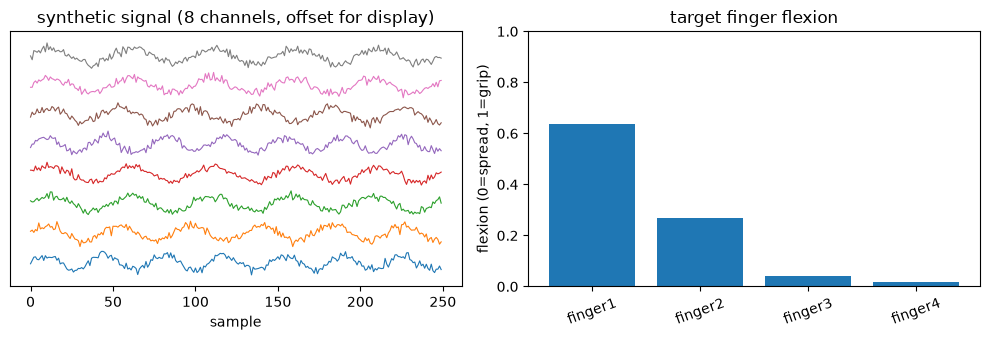

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

t = np.arange(N_TIMES)
for ch in range(N_CHANS):
    axes[0].plot(t, X0[ch] + ch * 4, linewidth=0.8)
axes[0].set_yticks([])
axes[0].set_xlabel("sample")
axes[0].set_title("synthetic signal (8 channels, offset for display)")

axes[1].bar(FINGERS, y0, color="tab:blue")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("flexion (0=spread, 1=grip)")
axes[1].set_title("target finger flexion")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## 2. 학습/검증용 합성 데이터셋 만들기

`make_synthetic_sample()`을 여러 번 호출해서 작은 데이터셋을 만들고 train/valid로 나눕니다.

In [4]:
N_SAMPLES = 200
X_all = np.zeros((N_SAMPLES, N_CHANS, N_TIMES), dtype=np.float32)
y_all = np.zeros((N_SAMPLES, len(FINGERS)), dtype=np.float32)
for i in range(N_SAMPLES):
    X_all[i], y_all[i] = make_synthetic_sample()

n_train = 160
X_train, y_train = X_all[:n_train], y_all[:n_train]
X_valid, y_valid = X_all[n_train:], y_all[n_train:]
print(f"train samples: {len(X_train)}, valid samples: {len(X_valid)}")

train samples: 160, valid samples: 40


## 3. `Decoder` 서브클래스: 손가락 굴곡도 회귀 모델

작은 1D-conv 회귀 모델을 `n2o.decoder.Regression`으로 감싸서, `decode(signal)`이
`{"finger1": 0.0-1.0, "finger2": 0.0-1.0, ...}` 형태의 연속값 명령을 반환하도록 합니다. `Decoder`를 직접
상속하지 않는 이유는 `Regression`이 연속값 타깃 디코더용 `preprocess()`/`window()`(각각
`bandpass_standardize()`/`window_by_sliding()`)를 이미 구현해두고 있어서, `decode()`만 새로 작성하면
되기 때문입니다. 마지막 레이어에 sigmoid를 둬서 출력을 굴곡도 범위인 [0, 1]로 제한합니다.
`output_type = FeatureType.ACTION`으로 선언하고 `config.type`을 `DecoderType.REGRESSION`으로 표시합니다.

In [ ]:
class FingerFlexionNet(torch.nn.Module):
    def __init__(self, n_chans, n_times, n_fingers):
        super().__init__()
        self.conv = torch.nn.Sequential(
            torch.nn.Conv1d(n_chans, 16, kernel_size=9, padding=4),
            torch.nn.ReLU(),
            torch.nn.AdaptiveAvgPool1d(1),
        )
        self.head = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(16, n_fingers),
            torch.nn.Sigmoid(),
        )

    def forward(self, x):
        return self.head(self.conv(x))


class FingerFlexionDecoder(Regression):
    """손가락별 연속 굴곡도(flexion)를 예측하는 회귀 디코더."""

    output_type = FeatureType.ACTION

    def __init__(self, n_chans, n_times):
        self.input_spec = {"n_chans": n_chans, "n_times": n_times}
        self.output_spec = {finger: "flexion in [0, 1]" for finger in FINGERS}
        self.config = DecoderConfig(type=DecoderType.REGRESSION)
        self.model = FingerFlexionNet(n_chans, n_times, n_fingers=len(FINGERS))

    def decode(self, signal):
        self.model.eval()
        with torch.no_grad():
            x = torch.tensor(signal).unsqueeze(0).float()
            flexion = self.model(x)[0]
        return {finger: float(v) for finger, v in zip(FINGERS, flexion)}


class FingerFlexionCommand(Command):
    """decoded_signal이 손가락별 flexion 값 dict이므로, 자기 자신을 설명하지 못하는 raw
    regression 값이라 `ActionType.JOINT_ABSOLUTE`로 태그해서 hand 쪽에 묶어 전달합니다."""

    def translate(self, decoder, decoded_signal):
        return {
            "type": decoder.config.type,
            "arm": None,
            "hand": (ActionType.JOINT_ABSOLUTE, decoded_signal),
        }


decoder = FingerFlexionDecoder(n_chans=N_CHANS, n_times=N_TIMES)
print(decoder.model)

## 4. 학습 sanity check (`MSELoss`)

분류가 아니라 회귀이므로 `CrossEntropyLoss` 대신 `MSELoss`를 씁니다. 합성 데이터 160개 전체를 반복
학습시켜서 loss가 떨어지는지만 확인합니다.

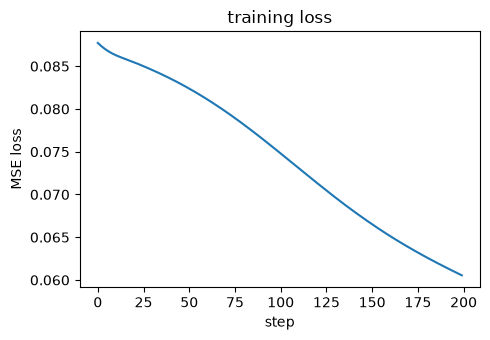

마지막 step MSE: 0.0605


In [6]:
decoder.model.train()
opt = torch.optim.Adam(decoder.model.parameters(), lr=1e-3)
loss_fn = torch.nn.MSELoss()

X_train_t = torch.from_numpy(X_train).float()
y_train_t = torch.from_numpy(y_train).float()

n_steps = 200
loss_history = []
for step in range(n_steps):
    opt.zero_grad()
    pred = decoder.model(X_train_t)
    loss = loss_fn(pred, y_train_t)
    loss.backward()
    opt.step()
    loss_history.append(loss.item())

plt.figure(figsize=(5, 3.5))
plt.plot(loss_history)
plt.xlabel("step")
plt.ylabel("MSE loss")
plt.title("training loss")
plt.tight_layout()
plt.show()

print(f"마지막 step MSE: {loss_history[-1]:.4f}")

## 5. 검증 샘플로 예측 vs 실제 비교

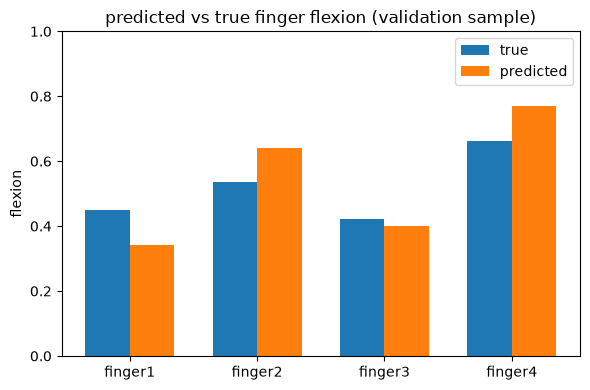

디코더 명령: {'finger1': 0.340967059135437, 'finger2': 0.6407396197319031, 'finger3': 0.401231974363327, 'finger4': 0.770205020904541}


In [7]:
sample_idx = 0
X_sample, y_sample = X_valid[sample_idx], y_valid[sample_idx]
predicted = decoder(X_sample)

x = np.arange(len(FINGERS))
width = 0.35
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - width / 2, y_sample, width, label="true")
ax.bar(x + width / 2, [predicted[f] for f in FINGERS], width, label="predicted")
ax.set_xticks(x)
ax.set_xticklabels(FINGERS)
ax.set_ylim(0, 1)
ax.set_ylabel("flexion")
ax.set_title("predicted vs true finger flexion (validation sample)")
ax.legend()
plt.tight_layout()
plt.show()

print("디코더 명령:", predicted)

## 6. MuJoCo로 실제 AmazingHand 모델 시각화하기

`04_hand_intent_classification_amazinghand.ipynb`와 같은 방식(`n2o.robot.Robot` +
`ControllerType.SIMULATION` + `n2o.robot.simulation.Simulator`)으로 시각화합니다.

다만 `AmazingHand.goal()`/`move()`는 아직 `GESTURES`에 있는 이름 있는 pose(문자열)만 받습니다
(`src/n2o/robot/hand/amazing_hand.py`의 `goal(self, cmd)`가 `GESTURES[cmd]` 단순 조회이기 때문) —
이 노트북처럼 손가락별 연속 굴곡도 dict(`(ActionType.JOINT_ABSOLUTE, {finger: flexion, ...})`)를
직접 받는 기능은 아직 없습니다. 그래서 여기서는 예측된 연속 굴곡도를 손가락 단위로 그대로 재현하는 대신,
평균 굴곡도가 높으면 `"grip"`, 낮으면 `"release"`로 근사해서 **가장 가까운 기존 named gesture**로만
보여줍니다 — 손가락별 세밀한 연속 제어가 실제로 되는 것처럼 보이면 안 되므로, 이건 어디까지나 근사적인
스탠드인이라는 점을 분명히 해둡니다. 진짜 손가락별 연속 제어를 붙이려면 `AmazingHand.goal()`이
`(ActionType, {finger: ...})` 형태도 처리하도록 먼저 확장해야 합니다.

In [ ]:
from n2o.robot import ControllerType, Robot
from n2o.robot.simulation import Simulator


def nearest_gesture(flexion: dict) -> str:
    """AmazingHand.goal()이 아직 손가락별 연속 굴곡도를 직접 받지 못하므로, 시각화 목적으로만
    평균 굴곡도를 grip(굴곡 높음)/release(굴곡 낮음) 중 가장 가까운 named gesture로 근사합니다 --
    실제 손가락별 세밀한 제어가 아닙니다."""
    mean_flexion = sum(flexion.values()) / len(flexion)
    return "grip" if mean_flexion >= 0.5 else "release"


demo_robot = Robot()
demo_robot.hand = AmazingHand()
demo_robot.controller = ControllerType.SIMULATION
demo_robot.simulator = Simulator()
demo_robot.simulator.launch_viewer("hand")

demo_flexions = [
    {"finger1": 0.0, "finger2": 0.0, "finger3": 0.0, "finger4": 0.0},  # 완전히 폄
    {"finger1": 1.0, "finger2": 1.0, "finger3": 1.0, "finger4": 1.0},  # 완전히 쥠
    predicted,  # 5절에서 예측한 검증 샘플의 굴곡도
]
for flexion in demo_flexions:
    gesture = nearest_gesture(flexion)
    print(f"flexion={flexion} -> nearest gesture={gesture!r}")
    demo_robot.router({"hand": gesture, "arm": None})

## 7. `N2O` 파이프라인으로 AmazingHand까지 명령 전달

`04_hand_intent_classification_amazinghand.ipynb`와 동일한 패턴으로 `N2O` 파이프라인을 구성합니다.
`n2o.robot.arm`은 이 노트북에서 쓰지 않으므로 `None`인 채로 둡니다.

**참고**: `FingerFlexionCommand`가 만드는 `(ActionType.JOINT_ABSOLUTE, {finger: flexion, ...})` 형태는
`AmazingHand.goal()`이 아직 지원하지 않는 형태입니다 (6절 참고) — `AmazingHand.goal(cmd)`는
`GESTURES[cmd]` 단순 문자열 조회만 하므로, dict를 담은 튜플을 그대로 넘기면 (dict가 unhashable이라)
`TypeError`가 납니다. 즉 아래 `n2o.run(controller="simulation")`은 **현재 코드베이스 기준으로
실패합니다** — 이는 이 노트북의 버그가 아니라 `AmazingHand`가 아직 연속값 명령을 처리하지 못한다는
실제 기능 공백입니다. 연속 굴곡도를 실제로 구동/시각화하려면 6절의 `nearest_gesture()` 근사를 거치거나,
`AmazingHand.goal()` 쪽에 `(ActionType, dict)` 지원을 먼저 추가해야 합니다.

In [ ]:
class OneShotSignal:
    """decoder()에 넘길 신호 한 개를 반복해서 돌려주는 최소 signal 소스."""

    def __init__(self, sample):
        self.sample = sample

    def read(self):
        return self.sample


n2o = N2O()
n2o.signal = OneShotSignal(X_sample)
n2o.decoder = decoder
n2o.command = FingerFlexionCommand()
n2o.robot.hand = AmazingHand()

n2o.command_config = CommandConfig()
print(n2o.command_config.verify_report(n2o))

In [ ]:
n2o.run(controller="simulation")

## 정리

- `n2o.decoder.Regression`을 상속한 회귀 모델이 `{finger_name: flexion}` 형태의 연속값 명령을 만들었고,
  `config.type = DecoderType.REGRESSION`으로 표시했습니다.
- AmazingHand의 실제 자유도(4개 손가락 x 굴곡/외전 2축)에 맞춰 `FINGERS`를 `finger1`~`finger4`로 두고,
  굴곡 축만 예측했습니다 (외전은 중립 고정). 합성 데이터와 `MSELoss` 기반 sanity-check 학습이라는 단순화
  지점은 남아있으니, 실제 EEG+운동학 데이터셋으로 교체할 때 그 부분만 바꾸면 됩니다.
- 회귀가 내놓는 raw flexion 값은 그 자체로 의미를 설명하지 못하므로, `FingerFlexionCommand`가
  `(ActionType.JOINT_ABSOLUTE, {finger: flexion, ...})` 튜플로 태그해서 `robot.hand`로 전달합니다
  (04번 노트북의 분류 결과가 `"grip"`처럼 이미 자기 설명적인 이름이었던 것과 대비됩니다).
- 하지만 `n2o.robot.hand.AmazingHand.goal()`/`move()`는 아직 named gesture 문자열만 받고, 이
  `(ActionType, dict)` 형태는 받지 못합니다 — 이 노트북에서 실제로 부딪힌 진짜 기능 공백입니다
  (7절 참고, `n2o.run(controller="simulation")`이 그대로 실패합니다). 손이 움직이는 모습은 대신 6절의
  `nearest_gesture()`로 예측 굴곡도를 가장 가까운 named gesture(`grip`/`release`)에 근사해서
  확인했습니다 — 손가락별 진짜 연속 제어가 아니라 스탠드인이라는 점에 유의하세요.
- `04_hand_intent_classification_amazinghand.ipynb`(분류)와 이 노트북(회귀)은 같은 `Decoder`/`N2O`/
  `AmazingHand`/`Simulator` 인터페이스를 공유하므로, 두 방식 중 어느 쪽으로 개발하더라도 로봇 손 연결
  코드의 큰 틀은 동일합니다 — 다만 raw 값이 자기 설명적인 이름인지(분류) 아닌지(회귀)에 따라 `Command`가
  붙이는 태그가 다르고, 그 결과 `AmazingHand`가 그 태그를 실제로 소화할 수 있는지도 달라집니다.